# Processamento da nuvem de pontos global do LiDAR principal

Este notebook processa o arquivo `posicao_lidar_imu.csv` ou `posicoes_lidar_imu.csv` para reconstruir a nuvem de pontos 3D do LiDAR principal no referencial global.

A transformação considera obrigatoriamente:

1. posição global do drone em cada amostra;
2. atitude global do drone, via matriz de rotação ou quaternions quando disponíveis;
3. ângulo instantâneo de varredura do LiDAR;
4. distância medida pelo LiDAR;
5. conversão do referencial local do LiDAR/drone para o referencial global.

A convenção adotada segue a hipótese de montagem do projeto: o LiDAR gira ao redor do eixo **Y** do drone. Assim, cada feixe está no plano local **X-Z**. O eixo `Y` do drone é tratado como eixo de giro, `X` como lateral e `Z` como vertical.

## Notas de unidade e referencial

Pelo firmware do projeto, a coluna `angle` é gravada como inteiro em centésimos de grau. O manual de desenvolvimento do LD06 também descreve os ângulos do pacote em unidade de `0,01 grau` e a distância em `mm`.

Referência usada para as constantes padrão: [LD06 Development Manual](https://storage.googleapis.com/mauser-public-images/prod_description_document/2021/315/8fcea7f5d479f4f4b71316d80b77ff45_096-6212_a.pdf).

Como existem versões antigas dos textos do TCC mencionando outra escala de distância, o fator `DISTANCE_SCALE_M` fica configurável. Se a calibração final indicar que o CSV usa outra unidade, altere apenas essa constante.

Modelo geométrico local adotado para o LiDAR girando em torno de `Y`:

$$
\mathbf{p}_{lidar} =
\begin{bmatrix}
 r\sin(\theta) \\
 0 \\
 r\cos(\theta)
\end{bmatrix}
$$

Nesse modelo, `theta = 0` aponta para `+Z` do drone e cresce na direção de `+X`. Se o zero físico do sensor estiver alinhado com outro eixo, ajuste `LIDAR_ANGLE_OFFSET_DEG` e `LIDAR_ANGLE_SIGN` na célula de configuração.

## Dependências

Este notebook usa `pandas`, `numpy`, `matplotlib` e `IPython.display`. Se alguma biblioteca não estiver disponível no kernel Jupyter escolhido, instale com:

```bash
pip install pandas numpy matplotlib
```


In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
except Exception:
    pass

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

pd.set_option('display.max_columns', 80)
pd.set_option('display.precision', 4)

## 1. Carregamento e inspeção inicial

O pedido cita `posicao_lidar_imu.csv`, mas o arquivo presente no projeto está como `posicoes_lidar_imu.csv`. A célula abaixo procura os dois nomes para evitar erro por diferença de singular/plural.

In [2]:
CSV_CANDIDATES = [
    Path('posicao_lidar_imu.csv'),
    Path('posicoes_lidar_imu.csv'),
]

csv_path = next((path for path in CSV_CANDIDATES if path.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        'Nenhum arquivo encontrado. Coloque posicao_lidar_imu.csv ou posicoes_lidar_imu.csv no diretório do notebook.'
    )

df_raw = pd.read_csv(csv_path)

print(f'Arquivo carregado: {csv_path.resolve()}')
print(f'Amostras: {len(df_raw):,}'.replace(',', '.'))
print(f'Colunas: {len(df_raw.columns)}')
display(df_raw.head())

Arquivo carregado: C:\Users\gabri\Documents\Ceub\Drone-Mapeamento\posicoes_lidar_imu.csv
Amostras: 6.241
Colunas: 9


,tempo_us,x,y,angle_x,angle_y,angle_z,angle,distance,intensity
0,11417907,0.0,0.0196,-14.099,0.6854,0.0,1197,11328,168
1,11417907,0.0,0.0196,-14.099,0.6854,0.0,4574,48113,2
2,11417907,0.0,0.0196,-14.099,0.6854,0.0,7952,44019,109
3,11417907,0.0,0.0196,-14.099,0.6854,0.0,11330,60418,109
4,11417907,0.0,0.0196,-14.099,0.6854,0.0,14708,11348,14


In [3]:
print('Colunas disponíveis:')
for col in df_raw.columns:
    print(f'- {col}')

missing_summary = pd.DataFrame({
    'ausentes': df_raw.isna().sum(),
    'percentual_%': 100 * df_raw.isna().mean(),
    'tipo_original': df_raw.dtypes.astype(str),
})

display(missing_summary)
display(df_raw.describe(include='all').T)

Colunas disponíveis:
- tempo_us
- x
- y
- angle_x
- angle_y
- angle_z
- angle
- distance
- intensity


,ausentes,percentual_%,tipo_original
tempo_us,0,0.0,int64
x,0,0.0,float64
y,0,0.0,float64
angle_x,0,0.0,float64
angle_y,0,0.0,float64
angle_z,0,0.0,float64
angle,0,0.0,int64
distance,0,0.0,int64
intensity,0,0.0,int64


,count,mean,std,min,25%,50%,75%,max
tempo_us,6241.0,3.8068e+07,1.4861e+07,1.0000,2.5665e+07,3.8013e+07,5.0795e+07,6.3484e+07
x,6241.0,1.2415e-01,8.3464e-02,0.0000,7.7444e-02,8.7257e-02,2.2711e-01,2.4633e-01
y,6241.0,3.0449e+00,2.4145e+00,0.0196,1.0880e+00,2.3308e+00,5.2603e+00,7.1912e+00
angle_x,6241.0,-1.3120e+01,1.2218e+00,-16.0369,-1.4033e+01,-1.3168e+01,-1.2223e+01,-9.9828e+00
angle_y,6241.0,9.4313e-01,1.2051e+00,-1.5416,-7.5507e-02,7.6935e-01,1.6430e+00,4.7028e+00
angle_z,6241.0,-4.5321e+00,3.9453e+00,-11.5140,-7.1526e+00,-5.4611e+00,0.0000e+00,2.0245e+00
angle,6241.0,1.5230e+04,1.0122e+04,0.0000,5.9320e+03,1.5215e+04,2.3417e+04,3.5998e+04
distance,6241.0,2.9875e+04,2.3264e+04,0.0000,4.0770e+03,2.9139e+04,5.4389e+04,6.5520e+04
intensity,6241.0,1.1485e+02,9.1967e+01,0.0000,1.4000e+01,1.1000e+02,2.1300e+02,2.5500e+02


## 2. Configuração explícita das colunas e unidades

As constantes abaixo concentram as decisões que dependem da montagem física e da calibração. A transformação principal não depende de filtros fixos, mas depende de convenções geométricas: eixo de giro, sentido angular, alinhamento LiDAR-corpo e escala de unidades.

No arquivo atual, há posição global em `x` e `y`, mas não há coluna de altitude. Quando `z` não existir, o notebook assume `z = 0 m`, isto é, trajetória global planar. Essa hipótese deve ser substituída por uma altitude medida/estimada assim que ela estiver disponível.

In [4]:
# Colunas do CSV processado
TIME_COL = 'tempo_us'
X_COL = 'x'
Y_COL = 'y'
Z_COL = 'z' if 'z' in df_raw.columns else None
LIDAR_ANGLE_COL = 'angle'
DISTANCE_COL = 'distance'
INTENSITY_COL = 'intensity'

# Atitude: usa quaternions se QUATERNION_COLUMNS for definido; caso contrário usa Euler ZYX.
EULER_COLUMNS = {
    'roll': 'angle_x',   # rotação em torno de X
    'pitch': 'angle_y',  # rotação em torno de Y
    'yaw': 'angle_z',    # rotação em torno de Z
}
QUATERNION_COLUMNS = None  # exemplo: {'qw': 'qw', 'qx': 'qx', 'qy': 'qy', 'qz': 'qz'}

# Unidades
ANGLE_SCALE_DEG = 0.01       # angle do LD06 em centésimos de grau
DISTANCE_SCALE_M = 0.001     # LD06: distância em mm -> m. Use 0.00025 se o pipeline confirmado usar 0,25 mm.
POSITION_SCALE_M = 1.0       # x,y,z já em metros no arquivo processado
ATTITUDE_SCALE_DEG = 1.0     # angle_x/y/z em graus

# Limite físico inferior do LD06. Não é um ajuste estatístico: é uma restrição física do sensor.
# Mantido configurável para caso a ficha técnica/calibração adotada no TCC seja diferente.
SENSOR_MIN_RANGE_M = 0.02

# Montagem do LiDAR no corpo do drone.
# Por padrão assume mesma origem/orientação do corpo; substitua pelos valores medidos de calibração extrínseca.
R_BODY_LIDAR = np.eye(3)
T_BODY_LIDAR_M = np.array([0.0, 0.0, 0.0])

# Convenção angular do LiDAR no plano X-Z ao redor de Y.
LIDAR_ANGLE_OFFSET_DEG = 0.0
LIDAR_ANGLE_SIGN = 1.0

required_cols = [TIME_COL, X_COL, Y_COL, LIDAR_ANGLE_COL, DISTANCE_COL, INTENSITY_COL]
if QUATERNION_COLUMNS is None:
    required_cols += list(EULER_COLUMNS.values())
else:
    required_cols += list(QUATERNION_COLUMNS.values())

missing_cols = [col for col in required_cols if col not in df_raw.columns]
if missing_cols:
    raise ValueError(f'Colunas obrigatórias ausentes: {missing_cols}')

print('Colunas obrigatórias encontradas.')
if Z_COL is None:
    print('Atenção: não há coluna z. Será usado z = 0 m para a posição global do drone.')

Colunas obrigatórias encontradas.
Atenção: não há coluna z. Será usado z = 0 m para a posição global do drone.


In [5]:
data = df_raw.copy()

numeric_cols = set(required_cols)
if Z_COL is not None:
    numeric_cols.add(Z_COL)

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

rows_before_dropna = len(data)
data = data.dropna(subset=list(numeric_cols)).copy()
rows_after_dropna = len(data)

if Z_COL is None:
    data['z_m'] = 0.0
else:
    data['z_m'] = data[Z_COL] * POSITION_SCALE_M

data['tempo_s_raw'] = (data[TIME_COL] - data[TIME_COL].iloc[0]) * 1e-6
data['lidar_angle_deg'] = data[LIDAR_ANGLE_COL] * ANGLE_SCALE_DEG
data['distance_m'] = data[DISTANCE_COL] * DISTANCE_SCALE_M
data['intensity'] = data[INTENSITY_COL]
data['x_m'] = data[X_COL] * POSITION_SCALE_M
data['y_m'] = data[Y_COL] * POSITION_SCALE_M

print(f'Linhas removidas por valores ausentes/não numéricos: {rows_before_dropna - rows_after_dropna}')
display(data[[TIME_COL, 'x_m', 'y_m', 'z_m', 'lidar_angle_deg', 'distance_m', 'intensity']].head())

Linhas removidas por valores ausentes/não numéricos: 0


,tempo_us,x_m,y_m,z_m,lidar_angle_deg,distance_m,intensity
0,11417907,0.0,0.0196,0.0,11.97,11.328,168
1,11417907,0.0,0.0196,0.0,45.74,48.113,2
2,11417907,0.0,0.0196,0.0,79.52,44.019,109
3,11417907,0.0,0.0196,0.0,113.30,60.418,109
4,11417907,0.0,0.0196,0.0,147.08,11.348,14


## 3. Análise exploratória

Antes de filtrar, os gráficos abaixo mostram a distribuição das variáveis que entram diretamente na nuvem de pontos: distância, intensidade, ângulo de varredura, posição e atitude. Essa etapa é importante para separar problemas de aquisição de decisões geométricas.

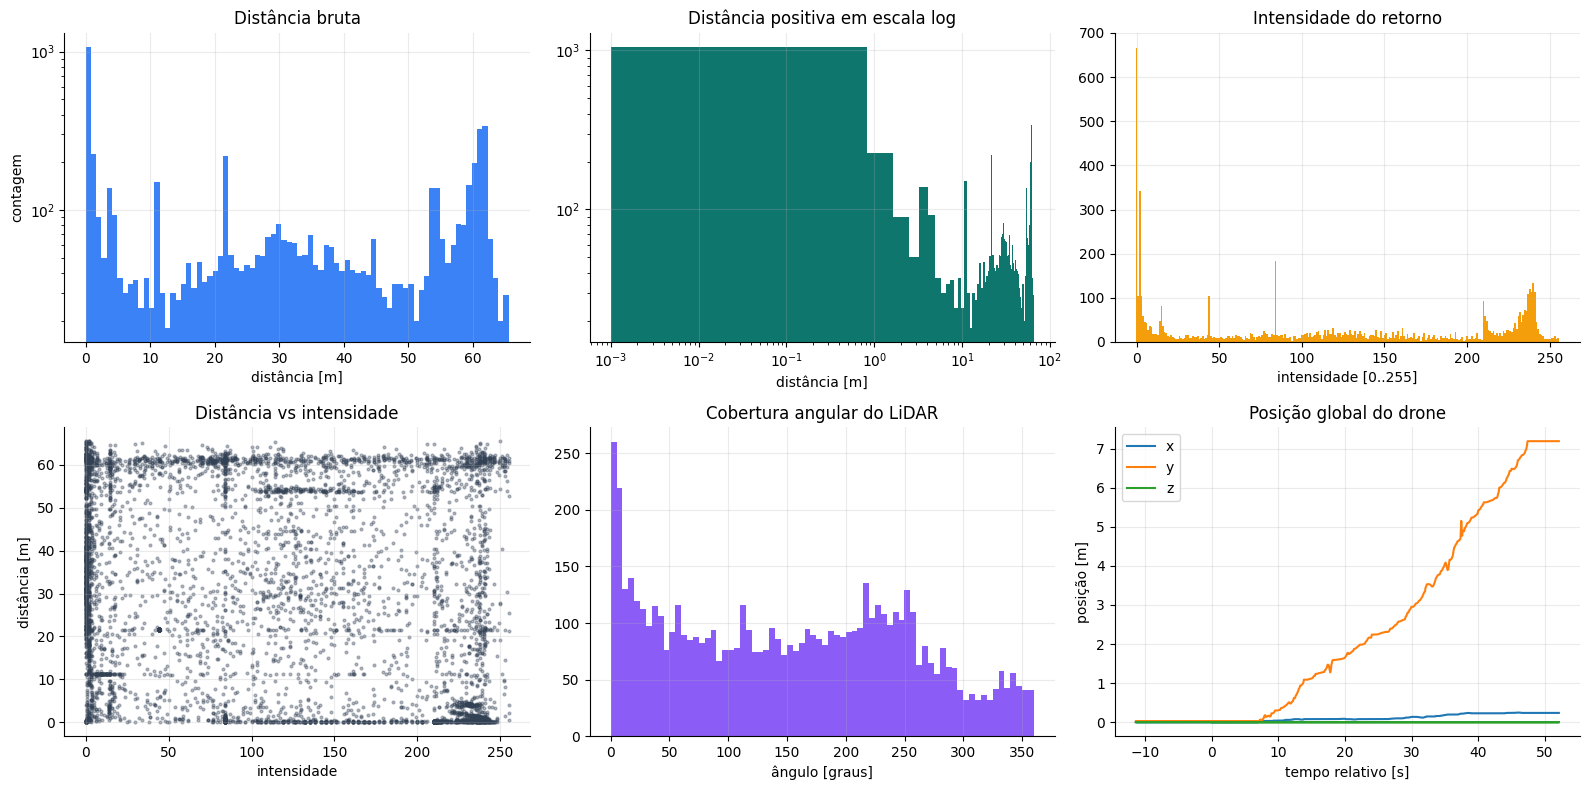

In [6]:
positive_distance = data.loc[data['distance_m'] > 0, 'distance_m']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(data['distance_m'], bins=80, color='#3b82f6')
axes[0, 0].set_title('Distância bruta')
axes[0, 0].set_xlabel('distância [m]')
axes[0, 0].set_ylabel('contagem')
axes[0, 0].set_yscale('log')

axes[0, 1].hist(positive_distance, bins=80, color='#0f766e')
axes[0, 1].set_title('Distância positiva em escala log')
axes[0, 1].set_xlabel('distância [m]')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')

axes[0, 2].hist(data['intensity'], bins=np.arange(-0.5, 256.5, 1), color='#f59e0b')
axes[0, 2].set_title('Intensidade do retorno')
axes[0, 2].set_xlabel('intensidade [0..255]')

axes[1, 0].scatter(data['intensity'], data['distance_m'], s=4, alpha=0.35, color='#334155')
axes[1, 0].set_title('Distância vs intensidade')
axes[1, 0].set_xlabel('intensidade')
axes[1, 0].set_ylabel('distância [m]')

axes[1, 1].hist(data['lidar_angle_deg'], bins=72, color='#8b5cf6')
axes[1, 1].set_title('Cobertura angular do LiDAR')
axes[1, 1].set_xlabel('ângulo [graus]')

axes[1, 2].plot(data['tempo_s_raw'], data['x_m'], label='x')
axes[1, 2].plot(data['tempo_s_raw'], data['y_m'], label='y')
axes[1, 2].plot(data['tempo_s_raw'], data['z_m'], label='z')
axes[1, 2].set_title('Posição global do drone')
axes[1, 2].set_xlabel('tempo relativo [s]')
axes[1, 2].set_ylabel('posição [m]')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

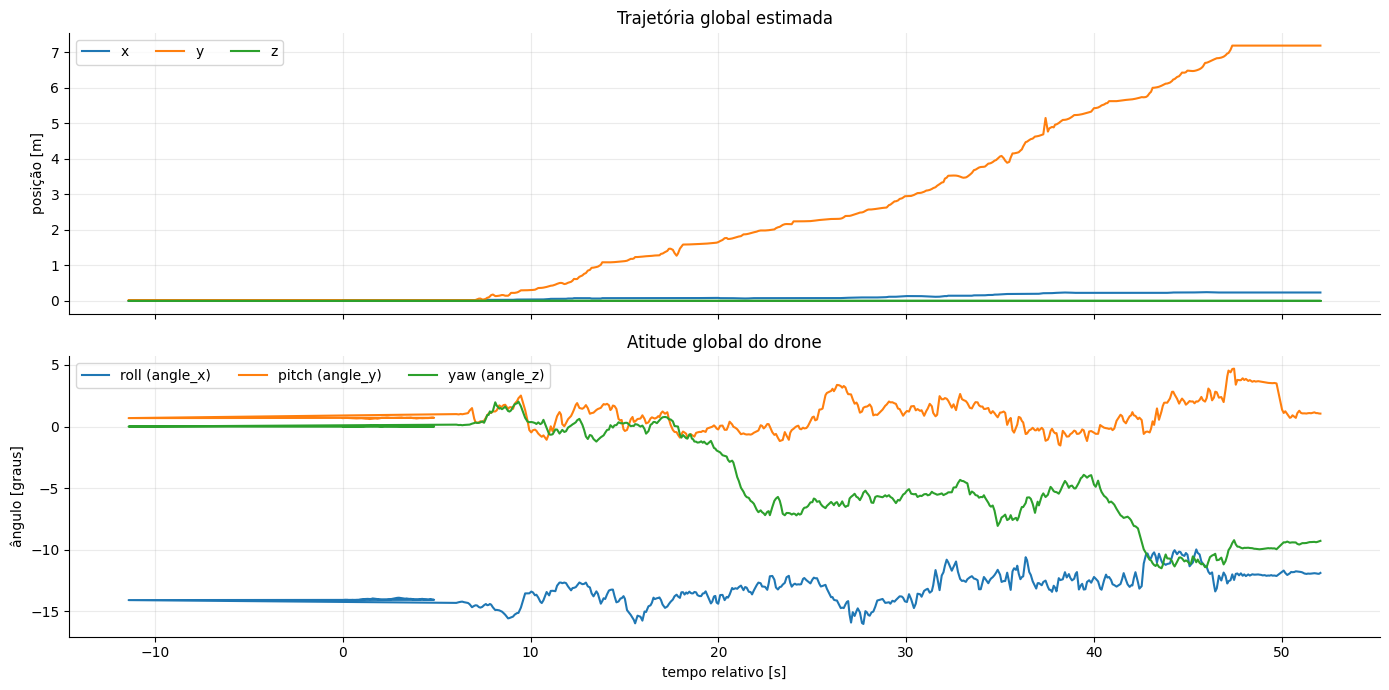

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(data['tempo_s_raw'], data['x_m'], label='x')
axes[0].plot(data['tempo_s_raw'], data['y_m'], label='y')
axes[0].plot(data['tempo_s_raw'], data['z_m'], label='z')
axes[0].set_ylabel('posição [m]')
axes[0].set_title('Trajetória global estimada')
axes[0].legend(ncol=3)

if QUATERNION_COLUMNS is None:
    for name, col in EULER_COLUMNS.items():
        axes[1].plot(data['tempo_s_raw'], data[col], label=f'{name} ({col})')
    axes[1].set_ylabel('ângulo [graus]')
else:
    for name, col in QUATERNION_COLUMNS.items():
        axes[1].plot(data['tempo_s_raw'], data[col], label=f'{name} ({col})')
    axes[1].set_ylabel('quaternion')

axes[1].set_title('Atitude global do drone')
axes[1].set_xlabel('tempo relativo [s]')
axes[1].legend(ncol=3)

plt.tight_layout()
plt.show()

## 4. Filtros com justificativa estatística e física

Os filtros aplicados são separados em critérios auditáveis:

- **Domínio físico do protocolo:** ângulo em `[0, 36000)`, intensidade em `[0, 255]`, distância positiva e acima do alcance físico mínimo configurado.
- **Integridade temporal:** `tempo_us` deve ser positivo e não decrescente na ordem de gravação. Uma queda brusca indica linha corrompida ou reinício de relógio.
- **Intensidade por Otsu:** o limiar é calculado automaticamente no histograma de intensidade, maximizando a separação entre duas populações: retornos fracos/ruído e retornos úteis.
- **Distância por Otsu em log:** após o filtro de intensidade, aplica-se Otsu sobre `log10(distance)`. A escala logarítmica é usada porque erros de alcance e saturações aparecem como ordens de grandeza diferentes, especialmente próximos do limite do `uint16`.
- **Continuidade de posição e atitude:** velocidades translacionais e angulares entre amostras sucessivas são avaliadas por cerca externa de Tukey (`Q3 + 3*IQR`). Esse critério remove saltos isolados sem impor uma velocidade máxima escolhida manualmente.

In [8]:
def otsu_threshold(values, bins=256, value_range=None, transform=None):
    """Calcula limiar de Otsu em 1D e retorna o valor no domínio original."""
    arr = np.asarray(pd.Series(values).dropna(), dtype=float)
    arr = arr[np.isfinite(arr)]
    if transform == 'log10':
        arr = arr[arr > 0]
        work = np.log10(arr)
    else:
        work = arr

    if work.size < 2 or np.nanmin(work) == np.nanmax(work):
        return np.nan, {'hist': None, 'edges': None, 'threshold_work': np.nan}

    hist, edges = np.histogram(work, bins=bins, range=value_range)
    centers = (edges[:-1] + edges[1:]) / 2
    total = hist.sum()

    weight_background = np.cumsum(hist)
    weight_foreground = total - weight_background
    sum_background = np.cumsum(hist * centers)
    sum_total = sum_background[-1]

    valid = (weight_background > 0) & (weight_foreground > 0)
    mean_background = np.divide(
        sum_background,
        weight_background,
        out=np.zeros_like(sum_background, dtype=float),
        where=weight_background > 0,
    )
    mean_foreground = np.divide(
        sum_total - sum_background,
        weight_foreground,
        out=np.zeros_like(sum_background, dtype=float),
        where=weight_foreground > 0,
    )

    score = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2
    score[~valid] = -np.inf
    idx = int(np.argmax(score))

    threshold_work = edges[idx + 1]
    threshold = 10 ** threshold_work if transform == 'log10' else threshold_work
    return threshold, {'hist': hist, 'edges': edges, 'threshold_work': threshold_work, 'score': score}


def tukey_outer_upper(values):
    """Cerca externa de Tukey: Q3 + 3*IQR, robusta contra outliers isolados."""
    arr = np.asarray(pd.Series(values).dropna(), dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 8:
        return np.inf
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    if iqr == 0:
        return np.inf
    return q3 + 3 * iqr


def state_continuity_mask(frame, base_mask):
    """Marca amostras cuja posição e atitude pertencem a uma sequência cinematicamente contínua."""
    mask = pd.Series(True, index=frame.index)
    state_cols = [TIME_COL, 'x_m', 'y_m', 'z_m']
    if QUATERNION_COLUMNS is None:
        state_cols += list(EULER_COLUMNS.values())
    else:
        return mask, {'speed_limit_m_s': np.inf, 'omega_limit_rad_s': np.inf}

    state = frame.loc[base_mask, state_cols].drop_duplicates(subset=TIME_COL, keep='first').copy()
    if len(state) < 8:
        return mask, {'speed_limit_m_s': np.inf, 'omega_limit_rad_s': np.inf}

    dt = state[TIME_COL].diff().to_numpy() * 1e-6
    dpos = state[['x_m', 'y_m', 'z_m']].diff().to_numpy()
    speed = np.full(len(state), np.nan)
    valid_dt = dt > 0
    speed[valid_dt] = np.linalg.norm(dpos[valid_dt], axis=1) / dt[valid_dt]

    euler_rad = np.deg2rad(state[list(EULER_COLUMNS.values())].to_numpy() * ATTITUDE_SCALE_DEG)
    euler_unwrapped = np.unwrap(euler_rad, axis=0)
    deuler = np.vstack([np.full(3, np.nan), np.diff(euler_unwrapped, axis=0)])
    omega = np.full(len(state), np.nan)
    omega[valid_dt] = np.linalg.norm(deuler[valid_dt], axis=1) / dt[valid_dt]

    speed_limit = tukey_outer_upper(speed)
    omega_limit = tukey_outer_upper(omega)
    state_ok = (np.isnan(speed) | (speed <= speed_limit)) & (np.isnan(omega) | (omega <= omega_limit))

    bad_times = set(state.loc[~state_ok, TIME_COL])
    if bad_times:
        mask = ~frame[TIME_COL].isin(bad_times)

    info = {
        'speed_limit_m_s': speed_limit,
        'omega_limit_rad_s': omega_limit,
        'bad_state_timestamps': len(bad_times),
    }
    return mask, info

In [9]:
finite_cols = [TIME_COL, X_COL, Y_COL, LIDAR_ANGLE_COL, DISTANCE_COL, INTENSITY_COL, 'distance_m', 'x_m', 'y_m', 'z_m']
if QUATERNION_COLUMNS is None:
    finite_cols += list(EULER_COLUMNS.values())
else:
    finite_cols += list(QUATERNION_COLUMNS.values())

masks = {}
masks['01_numerico_finito'] = np.logical_and.reduce([np.isfinite(data[col]) for col in finite_cols])
masks['02_tempo_positivo_e_crescente'] = (data[TIME_COL] > 0) & (data[TIME_COL].diff().fillna(0) >= 0)
masks['03_dominio_lidar'] = (
    data[LIDAR_ANGLE_COL].between(0, 36000, inclusive='left')
    & data[INTENSITY_COL].between(0, 255, inclusive='both')
)
masks['04_distancia_fisica_minima'] = data['distance_m'] >= SENSOR_MIN_RANGE_M

base_for_intensity = pd.Series(True, index=data.index)
for key in ['01_numerico_finito', '02_tempo_positivo_e_crescente', '03_dominio_lidar', '04_distancia_fisica_minima']:
    base_for_intensity &= masks[key]

raw_intensity_threshold, intensity_otsu_info = otsu_threshold(
    data.loc[base_for_intensity, INTENSITY_COL],
    bins=256,
    value_range=(0, 256),
)
intensity_threshold = float(np.ceil(raw_intensity_threshold))
masks['05_intensidade_otsu'] = data[INTENSITY_COL] >= intensity_threshold

base_for_distance = base_for_intensity & masks['05_intensidade_otsu']
distance_threshold_m, distance_otsu_info = otsu_threshold(
    data.loc[base_for_distance, 'distance_m'],
    bins=128,
    transform='log10',
)
masks['06_distancia_log_otsu'] = data['distance_m'] <= distance_threshold_m

base_before_state = base_for_distance & masks['06_distancia_log_otsu']
state_mask, state_info = state_continuity_mask(data, base_before_state)
masks['07_continuidade_posicao_atitude_tukey'] = state_mask

filter_order = list(masks.keys())
current_mask = pd.Series(True, index=data.index)
summary_rows = []
for key in filter_order:
    before = int(current_mask.sum())
    current_mask &= masks[key]
    after = int(current_mask.sum())
    summary_rows.append({
        'filtro': key,
        'antes': before,
        'removidos': before - after,
        'depois': after,
        'retencao_%': 100 * after / max(before, 1),
    })

filtered = data.loc[current_mask].copy()
filtered['tempo_s'] = (filtered[TIME_COL] - filtered[TIME_COL].iloc[0]) * 1e-6 if len(filtered) else []

thresholds = pd.DataFrame([
    {'criterio': 'intensidade por Otsu', 'limiar': intensity_threshold, 'unidade': 'escala 0..255'},
    {'criterio': 'distância mínima física', 'limiar': SENSOR_MIN_RANGE_M, 'unidade': 'm'},
    {'criterio': 'distância por Otsu em log10', 'limiar': distance_threshold_m, 'unidade': 'm'},
    {'criterio': 'velocidade translacional Tukey', 'limiar': state_info.get('speed_limit_m_s', np.inf), 'unidade': 'm/s'},
    {'criterio': 'velocidade angular Tukey', 'limiar': state_info.get('omega_limit_rad_s', np.inf), 'unidade': 'rad/s'},
])

print(f'Amostras após filtros: {len(filtered):,} de {len(data):,}'.replace(',', '.'))
display(thresholds)
display(pd.DataFrame(summary_rows))

display(filtered[[TIME_COL, 'x_m', 'y_m', 'z_m', 'lidar_angle_deg', 'distance_m', 'intensity']].head())

Amostras após filtros: 1.041 de 6.241


,criterio,limiar,unidade
0,intensidade por Otsu,121.0000,escala 0..255
1,distância mínima física,0.0200,m
2,distância por Otsu em log10,3.4071,m
3,velocidade translacional Tukey,0.9030,m/s
4,velocidade angular Tukey,0.2951,rad/s


,filtro,antes,removidos,depois,retencao_%
0,01_numerico_finito,6241,0,6241,100.0000
1,02_tempo_positivo_e_crescente,6241,1,6240,99.9840
2,03_dominio_lidar,6240,0,6240,100.0000
3,04_distancia_fisica_minima,6240,26,6214,99.5833
4,05_intensidade_otsu,6214,3315,2899,46.6527
5,06_distancia_log_otsu,2899,1820,1079,37.2197
6,07_continuidade_posicao_atitude_tukey,1079,38,1041,96.4782


,tempo_us,x_m,y_m,z_m,lidar_angle_deg,distance_m,intensity
14,11526609,0.0,0.0196,0.0,114.71,0.995,238
29,11672795,0.0,0.0196,0.0,19.36,0.726,239
40,11764577,0.0,0.0196,0.0,51.91,0.304,241
45,11764577,0.0,0.0196,0.0,115.25,0.751,236
64,11909834,0.0,0.0196,0.0,232.54,0.886,241


## 5. Validação visual dos filtros

Os gráficos comparam a distribuição antes/depois. As linhas verticais indicam os limiares calculados. Se a nuvem final parecer excessivamente pobre ou excessivamente ruidosa, esta é a célula principal para revisar a consequência dos filtros, mantendo o critério estatístico documentado.

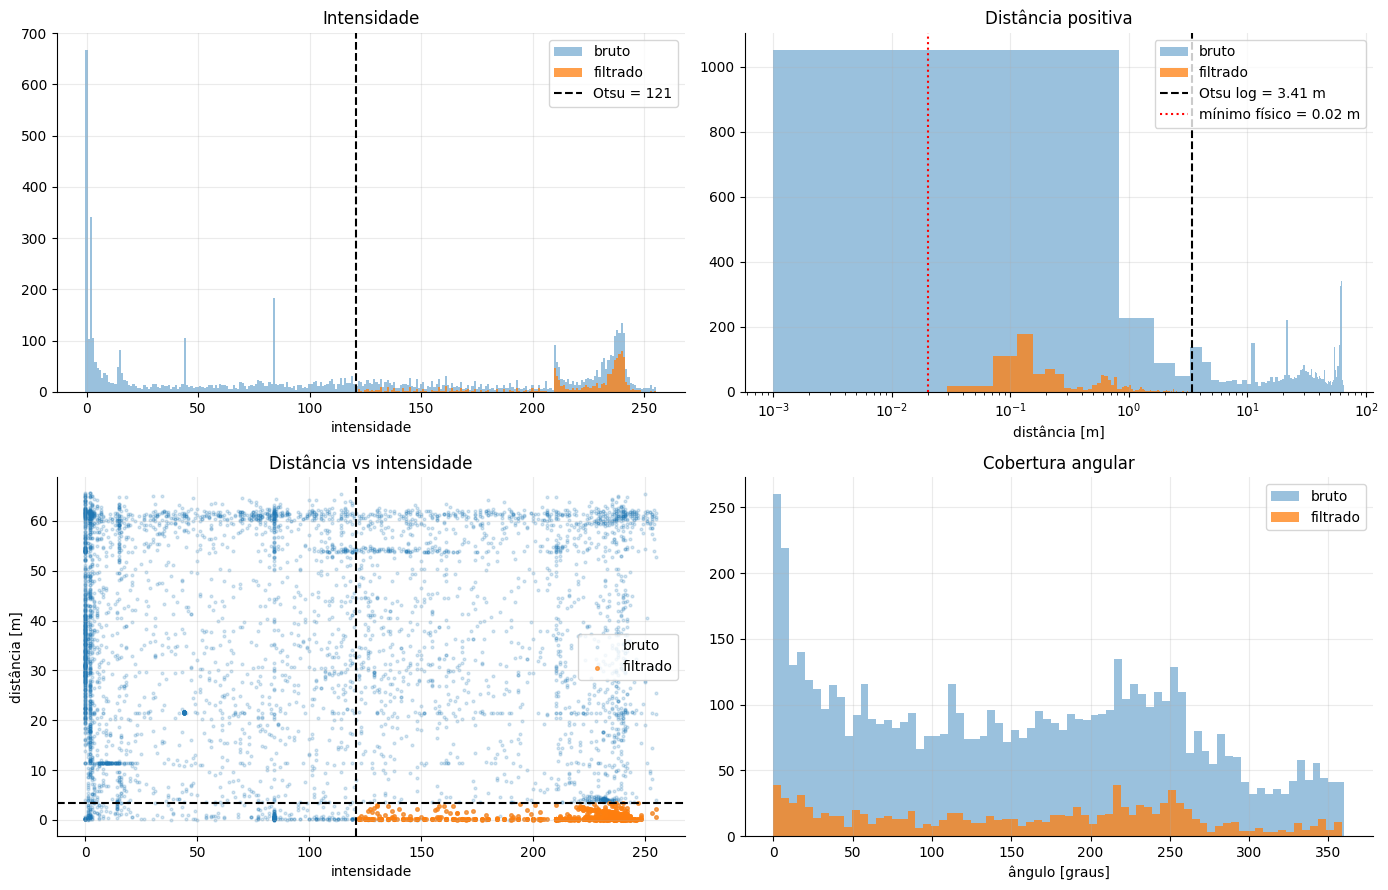

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(data[INTENSITY_COL], bins=np.arange(-0.5, 256.5, 1), alpha=0.45, label='bruto')
axes[0, 0].hist(filtered[INTENSITY_COL], bins=np.arange(-0.5, 256.5, 1), alpha=0.75, label='filtrado')
axes[0, 0].axvline(intensity_threshold, color='black', linestyle='--', label=f'Otsu = {intensity_threshold:.0f}')
axes[0, 0].set_title('Intensidade')
axes[0, 0].set_xlabel('intensidade')
axes[0, 0].legend()

positive_raw = data.loc[data['distance_m'] > 0, 'distance_m']
positive_filtered = filtered.loc[filtered['distance_m'] > 0, 'distance_m']
axes[0, 1].hist(positive_raw, bins=80, alpha=0.45, label='bruto')
axes[0, 1].hist(positive_filtered, bins=80, alpha=0.75, label='filtrado')
axes[0, 1].axvline(distance_threshold_m, color='black', linestyle='--', label=f'Otsu log = {distance_threshold_m:.2f} m')
axes[0, 1].axvline(SENSOR_MIN_RANGE_M, color='red', linestyle=':', label=f'mínimo físico = {SENSOR_MIN_RANGE_M:.2f} m')
axes[0, 1].set_title('Distância positiva')
axes[0, 1].set_xlabel('distância [m]')
axes[0, 1].set_xscale('log')
axes[0, 1].legend()

axes[1, 0].scatter(data[INTENSITY_COL], data['distance_m'], s=4, alpha=0.18, label='bruto')
axes[1, 0].scatter(filtered[INTENSITY_COL], filtered['distance_m'], s=7, alpha=0.65, label='filtrado')
axes[1, 0].axvline(intensity_threshold, color='black', linestyle='--')
axes[1, 0].axhline(distance_threshold_m, color='black', linestyle='--')
axes[1, 0].set_title('Distância vs intensidade')
axes[1, 0].set_xlabel('intensidade')
axes[1, 0].set_ylabel('distância [m]')
axes[1, 0].legend()

axes[1, 1].hist(data['lidar_angle_deg'], bins=72, alpha=0.45, label='bruto')
axes[1, 1].hist(filtered['lidar_angle_deg'], bins=72, alpha=0.75, label='filtrado')
axes[1, 1].set_title('Cobertura angular')
axes[1, 1].set_xlabel('ângulo [graus]')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 6. Transformação LiDAR/drone para global

A transformação final é:

$$
\mathbf{p}_{global} = \mathbf{R}_{global}^{corpo}\left(\mathbf{R}_{corpo}^{lidar}\mathbf{p}_{lidar} + \mathbf{t}_{corpo}^{lidar}\right) + \mathbf{s}_{drone}^{global}
$$

Onde:

- `p_lidar` vem da distância e do ângulo de varredura no plano `X-Z`;
- `R_BODY_LIDAR` e `T_BODY_LIDAR_M` representam a calibração extrínseca do LiDAR no corpo do drone;
- `R_global_corpo` é calculada por quaternions, se disponíveis, ou por Euler `Rz(yaw) @ Ry(pitch) @ Rx(roll)`;
- `s_drone_global` é a posição global do drone na amostra.

In [11]:
def euler_zyx_to_matrix(roll_rad, pitch_rad, yaw_rad):
    """Matriz corpo->global para Euler ZYX: Rz(yaw) @ Ry(pitch) @ Rx(roll)."""
    roll_rad = np.asarray(roll_rad)
    pitch_rad = np.asarray(pitch_rad)
    yaw_rad = np.asarray(yaw_rad)

    cr, sr = np.cos(roll_rad), np.sin(roll_rad)
    cp, sp = np.cos(pitch_rad), np.sin(pitch_rad)
    cy, sy = np.cos(yaw_rad), np.sin(yaw_rad)

    R = np.empty((roll_rad.size, 3, 3), dtype=float)
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr
    R[:, 2, 2] = cp * cr
    return R


def quaternion_to_matrix(qw, qx, qy, qz):
    """Matriz corpo->global a partir de quaternions normalizados no formato w,x,y,z."""
    q = np.column_stack([qw, qx, qy, qz]).astype(float)
    norm = np.linalg.norm(q, axis=1, keepdims=True)
    q = q / np.where(norm == 0, 1, norm)
    w, x, y, z = q.T

    R = np.empty((len(q), 3, 3), dtype=float)
    R[:, 0, 0] = 1 - 2 * (y * y + z * z)
    R[:, 0, 1] = 2 * (x * y - z * w)
    R[:, 0, 2] = 2 * (x * z + y * w)
    R[:, 1, 0] = 2 * (x * y + z * w)
    R[:, 1, 1] = 1 - 2 * (x * x + z * z)
    R[:, 1, 2] = 2 * (y * z - x * w)
    R[:, 2, 0] = 2 * (x * z - y * w)
    R[:, 2, 1] = 2 * (y * z + x * w)
    R[:, 2, 2] = 1 - 2 * (x * x + y * y)
    return R


def attitude_matrices(frame):
    if QUATERNION_COLUMNS is not None:
        return quaternion_to_matrix(
            frame[QUATERNION_COLUMNS['qw']].to_numpy(),
            frame[QUATERNION_COLUMNS['qx']].to_numpy(),
            frame[QUATERNION_COLUMNS['qy']].to_numpy(),
            frame[QUATERNION_COLUMNS['qz']].to_numpy(),
        )

    roll = np.deg2rad(frame[EULER_COLUMNS['roll']].to_numpy() * ATTITUDE_SCALE_DEG)
    pitch = np.deg2rad(frame[EULER_COLUMNS['pitch']].to_numpy() * ATTITUDE_SCALE_DEG)
    yaw = np.deg2rad(frame[EULER_COLUMNS['yaw']].to_numpy() * ATTITUDE_SCALE_DEG)
    return euler_zyx_to_matrix(roll, pitch, yaw)

In [12]:
if filtered.empty:
    raise ValueError('Nenhum ponto restou após os filtros. Revise os limiares e as unidades antes da transformação.')

theta_rad = np.deg2rad(
    LIDAR_ANGLE_SIGN * filtered['lidar_angle_deg'].to_numpy() + LIDAR_ANGLE_OFFSET_DEG
)
r = filtered['distance_m'].to_numpy()

# LiDAR girando ao redor de Y: varredura no plano X-Z do drone.
p_lidar = np.column_stack([
    r * np.sin(theta_rad),
    np.zeros_like(r),
    r * np.cos(theta_rad),
])

p_body = p_lidar @ R_BODY_LIDAR.T + T_BODY_LIDAR_M
R_world_body = attitude_matrices(filtered)
position_world = filtered[['x_m', 'y_m', 'z_m']].to_numpy()
p_world = np.einsum('nij,nj->ni', R_world_body, p_body) + position_world

cloud = filtered.copy()
cloud[['X_lidar_m', 'Y_lidar_m', 'Z_lidar_m']] = p_lidar
cloud[['X_body_m', 'Y_body_m', 'Z_body_m']] = p_body
cloud[['X_global_m', 'Y_global_m', 'Z_global_m']] = p_world

print(f'Pontos na nuvem global: {len(cloud):,}'.replace(',', '.'))
display(cloud[[TIME_COL, 'lidar_angle_deg', 'distance_m', 'intensity', 'X_global_m', 'Y_global_m', 'Z_global_m']].head())
display(cloud[['X_global_m', 'Y_global_m', 'Z_global_m']].describe().T)

Pontos na nuvem global: 1.041


,tempo_us,lidar_angle_deg,distance_m,intensity,X_global_m,Y_global_m,Z_global_m
14,11526609,114.71,0.995,238,0.8989,-0.0815,-0.4144
29,11672795,19.36,0.726,239,0.2487,0.1862,0.6614
40,11764577,51.91,0.304,241,0.2414,0.0653,0.1790
45,11764577,115.25,0.751,236,0.6755,-0.0587,-0.3188
64,11909834,232.54,0.886,241,-0.7094,-0.1117,-0.5143


,count,mean,std,min,25%,50%,75%,max
X_global_m,1041.0,0.1218,0.6047,-3.2977,-0.0710,0.1264,0.3173,2.7027
Y_global_m,1041.0,2.7561,2.3008,-0.5962,0.8748,2.2020,4.5465,7.7088
Z_global_m,1041.0,0.0067,0.6119,-2.7688,-0.2184,-0.0464,0.1434,3.2611


## 7. Visualizações intermediárias da transformação

O gráfico local verifica se a varredura está no plano `X-Z`, como exigido pela montagem com giro em torno de `Y`. O gráfico global mostra o efeito combinado de atitude e posição do drone.

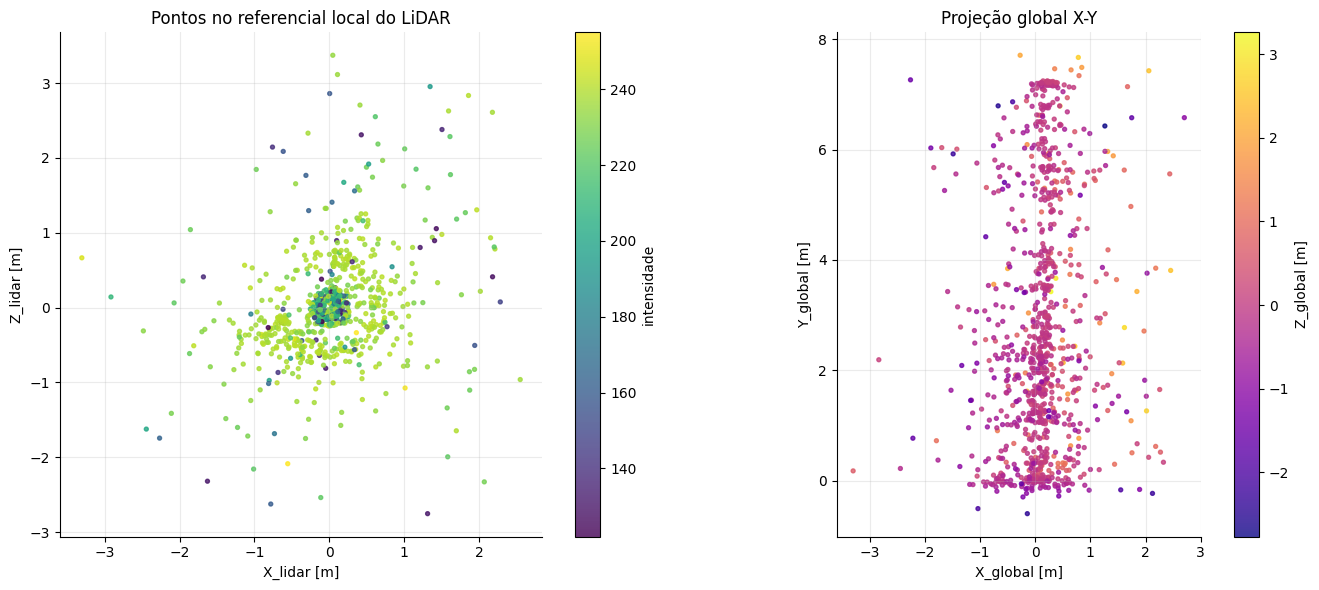

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(cloud['X_lidar_m'], cloud['Z_lidar_m'], c=cloud['intensity'], s=8, cmap='viridis', alpha=0.8)
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_title('Pontos no referencial local do LiDAR')
axes[0].set_xlabel('X_lidar [m]')
axes[0].set_ylabel('Z_lidar [m]')
plt.colorbar(sc0, ax=axes[0], label='intensidade')

sc1 = axes[1].scatter(cloud['X_global_m'], cloud['Y_global_m'], c=cloud['Z_global_m'], s=8, cmap='plasma', alpha=0.8)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title('Projeção global X-Y')
axes[1].set_xlabel('X_global [m]')
axes[1].set_ylabel('Y_global [m]')
plt.colorbar(sc1, ax=axes[1], label='Z_global [m]')

plt.tight_layout()
plt.show()

## 8. Nuvem de pontos 3D global

A visualização final usa cores por intensidade para facilitar a identificação de regiões com maior confiança do retorno. Em datasets maiores, `MAX_POINTS_PLOT` limita apenas a quantidade desenhada, não a nuvem exportada.

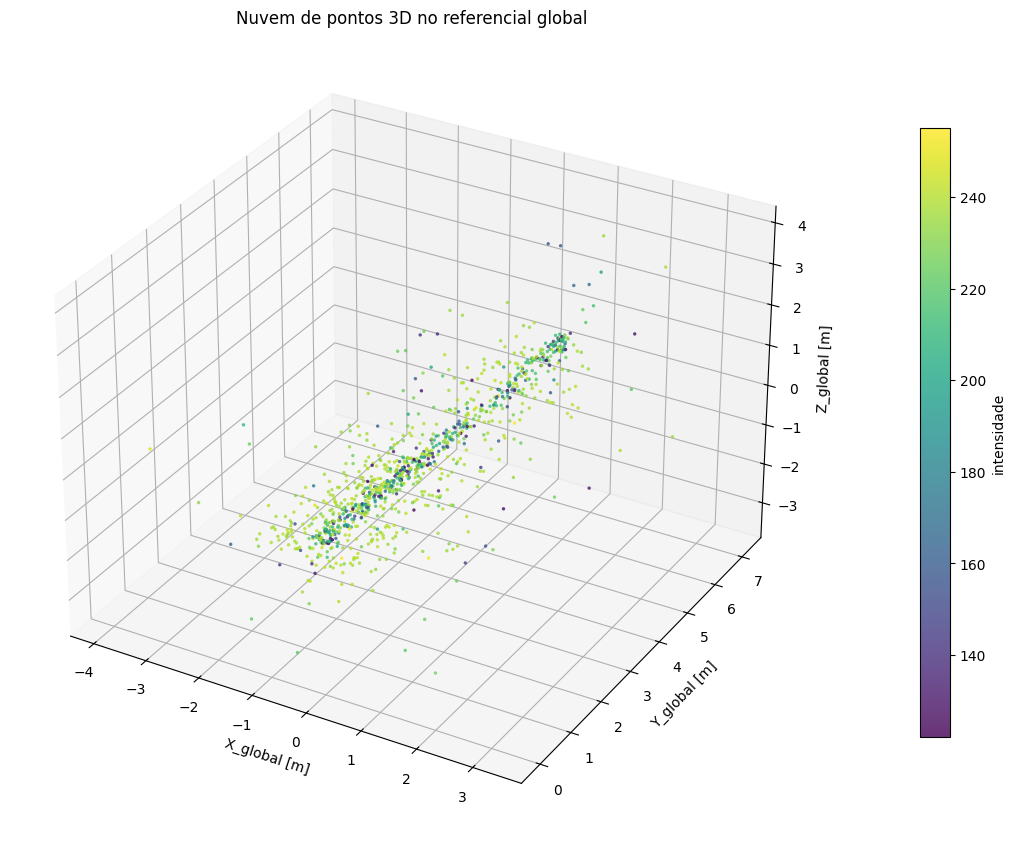

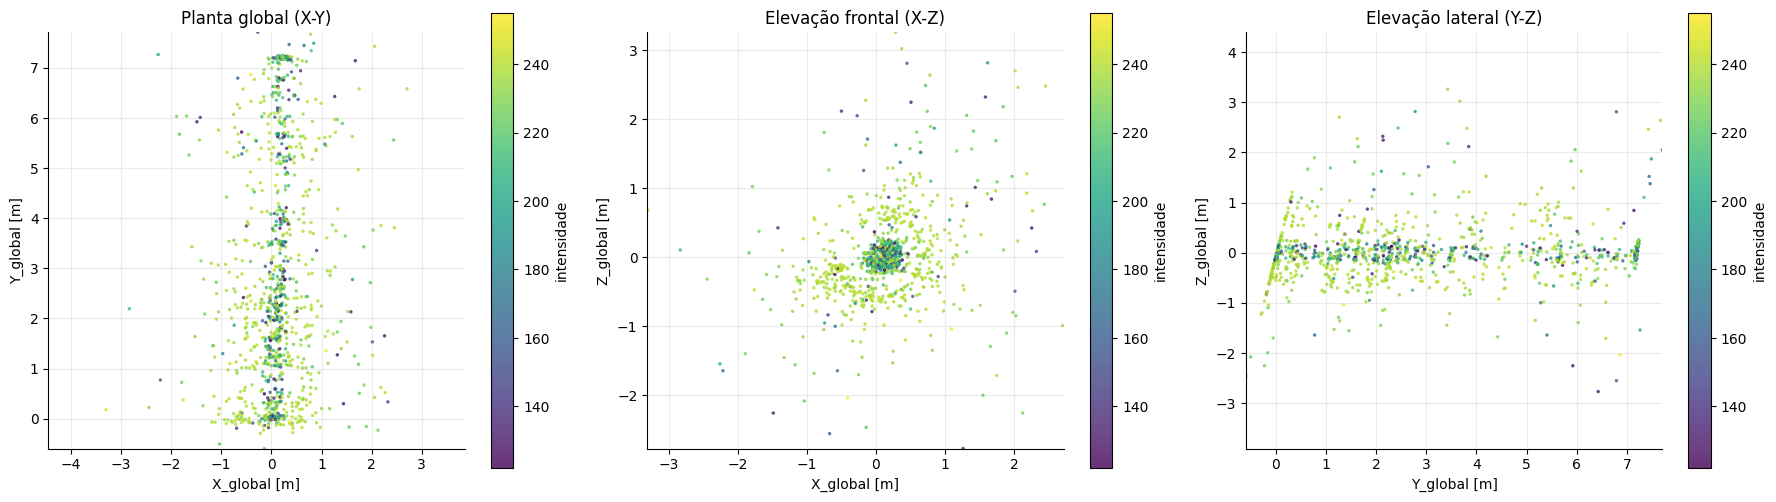

In [14]:
def set_axes_equal_3d(ax, xyz):
    xyz = np.asarray(xyz, dtype=float)
    mins = np.nanmin(xyz, axis=0)
    maxs = np.nanmax(xyz, axis=0)
    centers = (mins + maxs) / 2
    radius = 0.5 * np.nanmax(maxs - mins)
    if not np.isfinite(radius) or radius == 0:
        radius = 1.0
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)


def set_axes_equal_2d(ax, x, y):
    xy = np.column_stack([x, y]).astype(float)
    mins = np.nanmin(xy, axis=0)
    maxs = np.nanmax(xy, axis=0)
    centers = (mins + maxs) / 2
    radius = 0.5 * np.nanmax(maxs - mins)
    if not np.isfinite(radius) or radius == 0:
        radius = 1.0
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_aspect('equal', adjustable='box')


MAX_POINTS_PLOT = 50000
plot_cloud = cloud.sample(MAX_POINTS_PLOT, random_state=42) if len(cloud) > MAX_POINTS_PLOT else cloud

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    plot_cloud['X_global_m'],
    plot_cloud['Y_global_m'],
    plot_cloud['Z_global_m'],
    c=plot_cloud['intensity'],
    cmap='viridis',
    s=6,
    alpha=0.8,
    linewidths=0,
)

ax.set_title('Nuvem de pontos 3D no referencial global')
ax.set_xlabel('X_global [m]')
ax.set_ylabel('Y_global [m]')
ax.set_zlabel('Z_global [m]')
set_axes_equal_3d(ax, plot_cloud[['X_global_m', 'Y_global_m', 'Z_global_m']].to_numpy())
plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.1, label='intensidade')
plt.tight_layout()
plt.savefig('nuvem_global_3d.png', dpi=300)
plt.show()

orthogonal_views = [
    ('Planta global (X-Y)', 'X_global_m', 'Y_global_m'),
    ('Elevação frontal (X-Z)', 'X_global_m', 'Z_global_m'),
    ('Elevação lateral (Y-Z)', 'Y_global_m', 'Z_global_m'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, (title, x_col, y_col) in zip(axes, orthogonal_views):
    sc = axis.scatter(
        plot_cloud[x_col],
        plot_cloud[y_col],
        c=plot_cloud['intensity'],
        cmap='viridis',
        s=6,
        alpha=0.8,
        linewidths=0,
    )
    axis.set_title(title)
    axis.set_xlabel(x_col.replace('_m', ' [m]'))
    axis.set_ylabel(y_col.replace('_m', ' [m]'))
    set_axes_equal_2d(axis, plot_cloud[x_col], plot_cloud[y_col])
    plt.colorbar(sc, ax=axis, label='intensidade')

plt.tight_layout()
plt.savefig('nuvem_global_2d.png', dpi=300)
plt.show()

## 9. Exportação da nuvem processada

A célula abaixo salva um CSV com as coordenadas locais, no corpo do drone e globais. Esse arquivo pode ser importado em ferramentas externas de nuvem de pontos ou usado em etapas posteriores do TCC.

In [15]:
output_path = Path('nuvem_pontos_lidar_global.csv')

export_cols = [
    TIME_COL,
    'x_m', 'y_m', 'z_m',
    'lidar_angle_deg', 'distance_m', 'intensity',
    'X_lidar_m', 'Y_lidar_m', 'Z_lidar_m',
    'X_body_m', 'Y_body_m', 'Z_body_m',
    'X_global_m', 'Y_global_m', 'Z_global_m',
]

cloud[export_cols].to_csv(output_path, index=False)
print(f'Nuvem exportada para: {output_path.resolve()}')
print(f'Pontos exportados: {len(cloud):,}'.replace(',', '.'))

Nuvem exportada para: C:\Users\gabri\Documents\Ceub\Drone-Mapeamento\nuvem_pontos_lidar_global.csv
Pontos exportados: 1.041


## 10. Pontos de calibração a revisar no TCC

Este notebook deixa explícitas as hipóteses que mais influenciam a geometria final:

- `DISTANCE_SCALE_M`: confirmar no texto final se a distância é `mm` ou outra unidade do pipeline.
- `LIDAR_ANGLE_OFFSET_DEG` e `LIDAR_ANGLE_SIGN`: calibrar o zero e o sentido físico do LD06 depois da montagem.
- `R_BODY_LIDAR` e `T_BODY_LIDAR_M`: substituir identidade/zero por calibração extrínseca real entre LiDAR e corpo do drone.
- `z_m`: substituir a hipótese planar por altitude estimada/medida quando disponível.
- filtros automáticos: manter os histogramas e a tabela de retenção no TCC para justificar quantitativamente os limiares escolhidos.

## 10. Análise de erro dimensional com referência experimental

As dimensões de referência do corredor foram medidas experimentalmente em três repetições para cada dimensão horizontal, buscando reduzir erros aleatórios de medição manual. Os valores consolidados adotados como referência são:

- largura: $1{,}20~\text{m}$;
- comprimento: $7{,}00~\text{m}$.

Não há medida real confiável da altura do teto. Por isso, a dimensão vertical não é usada para cálculo de erro dimensional.

A largura é estimada pela extensão da nuvem no eixo `X_global_m`, enquanto o comprimento é estimado pela extensão no eixo `Y_global_m`, coerente com a trajetória predominante do ensaio. Como poucos retornos isolados podem deslocar os mínimos e máximos da nuvem, a métrica principal usa a amplitude robusta entre os percentis 5% e 95%. A amplitude bruta é mantida apenas como diagnóstico de sensibilidade aos extremos.

O erro absoluto e o erro relativo percentual são calculados por:

$$
e_{abs} = |x_{estimado} - x_{real}|
$$

$$
e_{rel}(\%) = \frac{|x_{estimado} - x_{real}|}{x_{real}} \cdot 100
$$

Essa análise é uma validação geométrica preliminar no plano horizontal. Ela não valida a localização absoluta nem a dimensão vertical do ambiente.


In [16]:
REFERENCE_DIMENSIONS_M = pd.DataFrame([
    {'dimensao': 'Largura', 'valor_real_m': 1.20, 'eixo_nuvem': 'X_global_m'},
    {'dimensao': 'Comprimento', 'valor_real_m': 7.00, 'eixo_nuvem': 'Y_global_m'},
])

ROBUST_QUANTILE_LOW = 0.05
ROBUST_QUANTILE_HIGH = 0.95
ROBUST_CRITERION_LABEL = f'P{int(ROBUST_QUANTILE_LOW * 100)}-P{int(ROBUST_QUANTILE_HIGH * 100)}'


def horizontal_extent_summary(frame, axis_col):
    series = pd.to_numeric(frame[axis_col], errors='coerce').dropna()
    series = series[np.isfinite(series)]
    if series.empty:
        return {
            'eixo_nuvem': axis_col,
            'pontos_validos': 0,
            'min_bruto_m': np.nan,
            'max_bruto_m': np.nan,
            'amplitude_bruta_m': np.nan,
            'p05_m': np.nan,
            'p95_m': np.nan,
            'amplitude_robusta_m': np.nan,
        }

    raw_min = float(series.min())
    raw_max = float(series.max())
    robust_min = float(series.quantile(ROBUST_QUANTILE_LOW))
    robust_max = float(series.quantile(ROBUST_QUANTILE_HIGH))
    return {
        'eixo_nuvem': axis_col,
        'pontos_validos': int(series.size),
        'min_bruto_m': raw_min,
        'max_bruto_m': raw_max,
        'amplitude_bruta_m': raw_max - raw_min,
        'p05_m': robust_min,
        'p95_m': robust_max,
        'amplitude_robusta_m': robust_max - robust_min,
    }


horizontal_axes = REFERENCE_DIMENSIONS_M['eixo_nuvem'].tolist()
extensoes_horizontais = pd.DataFrame([
    horizontal_extent_summary(cloud, axis_col) for axis_col in horizontal_axes
])

erro_dimensional = REFERENCE_DIMENSIONS_M.merge(extensoes_horizontais, on='eixo_nuvem', how='left')
erro_dimensional['valor_estimado_m'] = erro_dimensional['amplitude_robusta_m']
erro_dimensional['erro_absoluto_m'] = (
    erro_dimensional['valor_estimado_m'] - erro_dimensional['valor_real_m']
).abs()
erro_dimensional['erro_relativo_%'] = (
    erro_dimensional['erro_absoluto_m'] / erro_dimensional['valor_real_m'] * 100
)
erro_dimensional['criterio_estimativa'] = f'amplitude robusta {ROBUST_CRITERION_LABEL}'

display(
    extensoes_horizontais[[
        'eixo_nuvem', 'pontos_validos', 'min_bruto_m', 'max_bruto_m', 'amplitude_bruta_m',
        'p05_m', 'p95_m', 'amplitude_robusta_m',
    ]].round(4)
)

display(
    erro_dimensional[[
        'dimensao', 'valor_real_m', 'eixo_nuvem', 'valor_estimado_m',
        'erro_absoluto_m', 'erro_relativo_%', 'criterio_estimativa',
    ]].round({
        'valor_real_m': 3,
        'valor_estimado_m': 3,
        'erro_absoluto_m': 3,
        'erro_relativo_%': 2,
    })
)

print('Observação: a altura/teto não foi usada na análise, pois não há medida real confiável para validação vertical.')
print('A amplitude bruta é apresentada apenas como diagnóstico; a tabela de erro usa a amplitude robusta P5-P95.')


,eixo_nuvem,pontos_validos,min_bruto_m,max_bruto_m,amplitude_bruta_m,p05_m,p95_m,amplitude_robusta_m
0,X_global_m,1041,-3.2977,2.7027,6.0004,-0.8296,1.1217,1.9514
1,Y_global_m,1041,-0.5962,7.7088,8.3050,-0.0242,7.1601,7.1843


,dimensao,valor_real_m,eixo_nuvem,valor_estimado_m,erro_absoluto_m,erro_relativo_%,criterio_estimativa
0,Largura,1.2,X_global_m,1.951,0.751,62.61,amplitude robusta P5-P95
1,Comprimento,7.0,Y_global_m,7.184,0.184,2.63,amplitude robusta P5-P95


Observação: a altura/teto não foi usada na análise, pois não há medida real confiável para validação vertical.
A amplitude bruta é apresentada apenas como diagnóstico; a tabela de erro usa a amplitude robusta P5-P95.
